# Phase 2 — Multimodal Fusion: Image + Radiology Report
## PneumoFusionNet | MIMIC-CXR PA Cohort (~1,880 samples)

**Best Phase-1 checkpoint used:** `best_model_fold2.pth`
- Fold 2 achieved the highest TTA AUC = **0.8445** and Tuned Acc = **77.6%** across all 5 folds.

### Pipeline
```
Image  --> DenseNet121+CBAM (Fold2, frozen) --> 1024-d image embedding
Report --> ClinicalBERT (frozen)            -->  768-d text  embedding
                                                     |
                                Concat Fusion --> MLP Classifier --> label
```
**Training strategy:** Single 70/15/15 stratified split (train/val/test) — clean, fast, no loop overhead.


In [1]:
# --- CELL 0: Imports & Reproducibility ---
import os, random, warnings, json, copy, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from transformers import AutoTokenizer, AutoModel
import torchxrayvision as xrv

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, accuracy_score, f1_score)

# ── Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")


Device : cuda
PyTorch: 2.5.1+cu121


In [2]:
# --- CELL 1: Configuration ---
BASE_DIR  = r"c:\\2026\\PneumoFusionNet\\mimic\\1000_dataset"

# *** Updated: use pre-cleaned CSV (IMPRESSION removed, leakage words redacted) ***
CSV_PATH  = os.path.join(BASE_DIR, "phase2_reports_no_impression.csv")

BBOX_CSV  = os.path.join(BASE_DIR, "outputs", "Phase_1.1v2_PA_enhanced", "lung_bboxes.csv")

# Best Phase-1 checkpoint (Fold 2 - highest TTA AUC = 0.8445)
P1_CKPT   = os.path.join(BASE_DIR, "outputs", "Phase_1.1v4_PA_crossval", "best_model_fold2.pth")

SAVE_DIR  = os.path.join(BASE_DIR, "outputs", "Phase_2_multimodal")
os.makedirs(SAVE_DIR, exist_ok=True)

# Model dims
IMG_SIZE       = 224
MAX_TEXT_LEN   = 256
CLINBERT_MODEL = "emilyalsentzer/Bio_ClinicalBERT"
IMG_FEAT_DIM   = 1024
TXT_FEAT_DIM   = 768
FUSION_HIDDEN  = 512

# Training
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
BATCH_SIZE   = 16
LR           = 2e-4
EPOCHS       = 40
PATIENCE     = 8
CLASSES      = ['NORMAL', 'PNEUMONIA']
MEAN = [0.5020]
STD  = [0.2703]

print(f"CSV              : {CSV_PATH}")
print(f"CSV exists?      : {os.path.exists(CSV_PATH)}")
print(f"Phase-1 ckpt     : {P1_CKPT}")
print(f"Checkpoint exists: {os.path.exists(P1_CKPT)}")


CSV              : c:\\2026\\PneumoFusionNet\\mimic\\1000_dataset\phase2_reports_no_impression.csv
CSV exists?      : True
Phase-1 ckpt     : c:\\2026\\PneumoFusionNet\\mimic\\1000_dataset\outputs\Phase_1.1v4_PA_crossval\best_model_fold2.pth
Checkpoint exists: True


In [3]:
# --- CELL 2: Data Loading from pre-cleaned CSV ---
df = pd.read_csv(CSV_PATH)

def resolve_path(p):
    if pd.isna(p) or str(p).strip() == '':
        return ''
    p = str(p).replace('/', os.sep).replace('\\\\', os.sep)
    return p if os.path.isabs(p) else os.path.join(BASE_DIR, p)

df['image_path'] = df['image_path'].apply(resolve_path)

# The CSV already has 'report_no_impression' column -- use it directly
# No need to read .txt files or extract sections in Cell 4 anymore
df['report_clean'] = df['report_no_impression'].fillna('').astype(str)

print(f"Loaded rows : {len(df)}")
print(df['label'].value_counts().rename({0: 'Normal', 1: 'Pneumonia'}))


Loaded rows : 1989
Normal       1062
Pneumonia     927
Name: label, dtype: int64


  PHASE 2 DATASET SANITY CHECK

[1] Shape        : (1989, 11)
    Columns      : ['patient_id', 'subject_id', 'study_id', 'image_path', 'report_path', 'view_position', 'label', 'pneumonia_label', 'no_finding_label', 'report_no_impression', 'report_clean']

[2] Label distribution:
    Normal    : 1062
    Pneumonia : 927
    Balance ratio : 0.873 (1.0 = perfect balance)
    OK: Dataset is roughly balanced.

[3] Missing values per column:
    image_path          : OK
    label               : OK
    report_clean        : OK

[4] Image files on disk:
    Found   : 1989/1989
    OK: All image files exist.

[5] Report text quality:
    Empty reports    : 0
    Avg word count   : 65.6
    Min word count   : 2
    Max word count   : 305

[6] IMPRESSION leakage check:
    Reports still containing IMPRESSION : 0
    Reports still containing pneumonia  : 0
    Reports still containing "no acute" : 20
    OK: No leakage keywords detected.

[7] Duplicate check:
    Duplicate image paths  : 0
    D

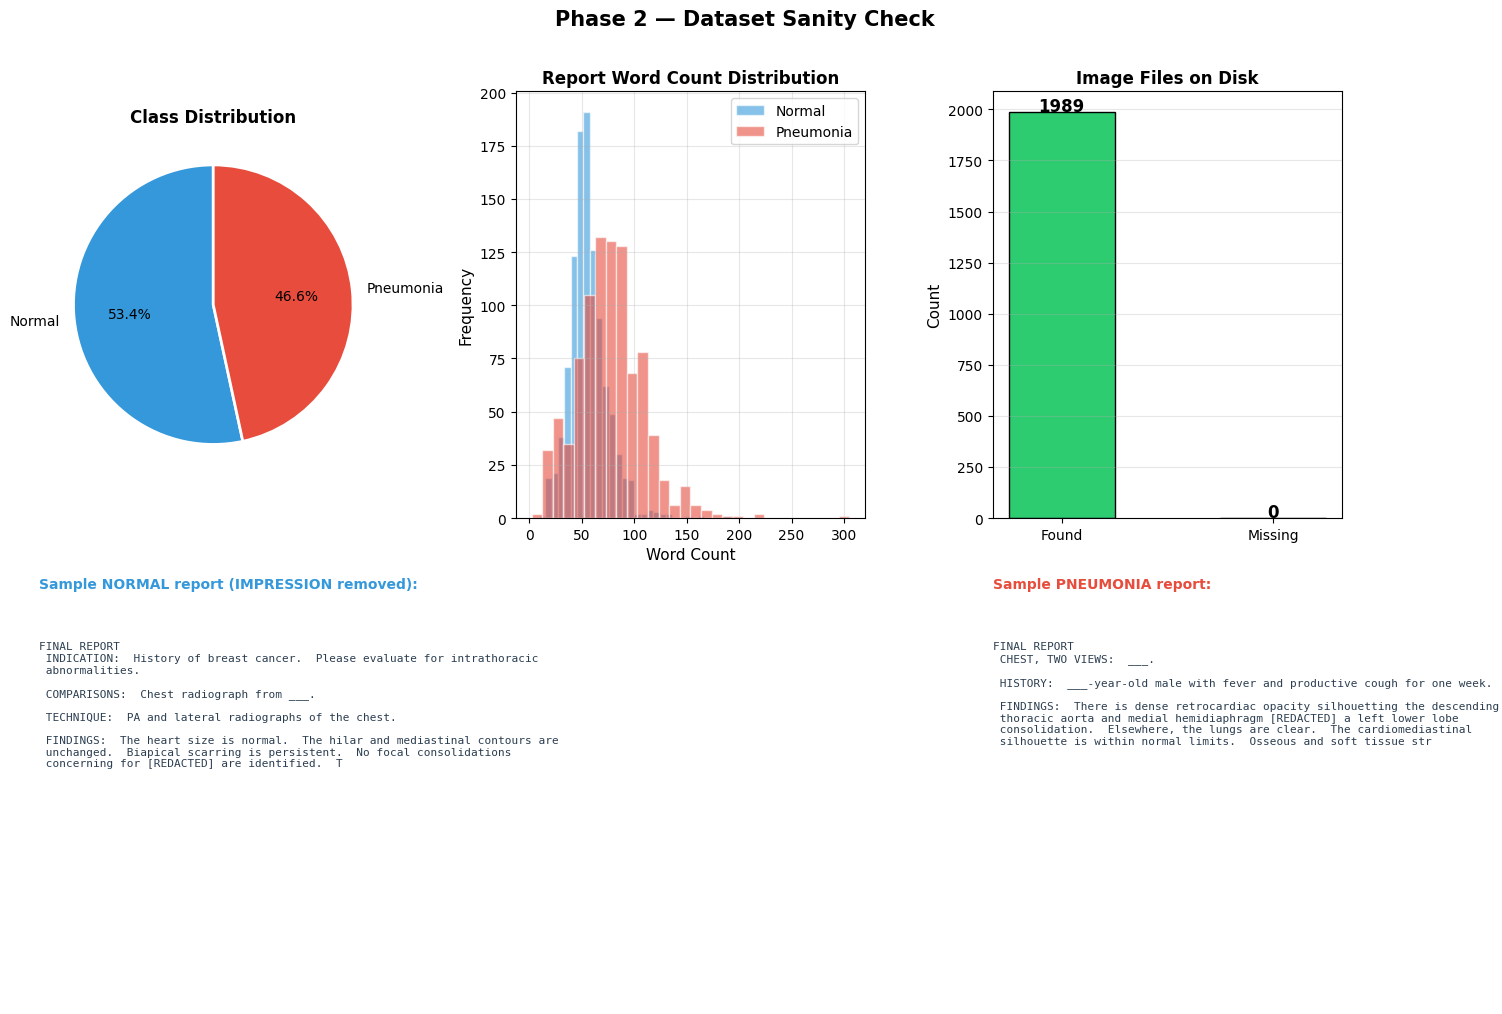


  SANITY CHECK COMPLETE


In [4]:
# --- CELL 2b: Dataset Sanity Check ---
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print('=' * 60)
print('  PHASE 2 DATASET SANITY CHECK')
print('=' * 60)

# ── 1. Basic shape ────────────────────────────────────────────
print(f'\n[1] Shape        : {df.shape}')
print(f'    Columns      : {df.columns.tolist()}')

# ── 2. Label distribution ────────────────────────────────────
label_counts = df['label'].value_counts().rename({0:'Normal', 1:'Pneumonia'})
print(f'\n[2] Label distribution:')
print(f'    Normal    : {label_counts.get("Normal",0)}')
print(f'    Pneumonia : {label_counts.get("Pneumonia",0)}')
ratio = label_counts.min() / label_counts.max()
print(f'    Balance ratio : {ratio:.3f} (1.0 = perfect balance)')
if ratio < 0.8:
    print('    WARNING: Dataset is imbalanced — class weighting will be applied.')
else:
    print('    OK: Dataset is roughly balanced.')

# ── 3. Missing values ────────────────────────────────────────
print(f'\n[3] Missing values per column:')
missing = df[['image_path','label','report_clean']].isnull().sum()
for col, cnt in missing.items():
    status = 'OK' if cnt == 0 else f'WARNING: {cnt} missing'
    print(f'    {col:20s}: {status}')

# ── 4. Image file existence ───────────────────────────────────
print(f'\n[4] Image files on disk:')
img_exists = df['image_path'].apply(os.path.exists)
print(f'    Found   : {img_exists.sum()}/{len(df)}')
missing_imgs = (~img_exists).sum()
if missing_imgs > 0:
    print(f'    WARNING: {missing_imgs} images NOT found on disk!')
    print(df[~img_exists]['image_path'].head(3).tolist())
else:
    print('    OK: All image files exist.')

# ── 5. Report text quality ────────────────────────────────────
print(f'\n[5] Report text quality:')
empty_reports = (df['report_clean'].str.strip() == '').sum()
word_counts   = df['report_clean'].str.split().str.len()
print(f'    Empty reports    : {empty_reports}')
print(f'    Avg word count   : {word_counts.mean():.1f}')
print(f'    Min word count   : {word_counts.min()}')
print(f'    Max word count   : {word_counts.max()}')
short = (word_counts < 10).sum()
if short > 0:
    print(f'    WARNING: {short} reports have < 10 words (very short).')
else:
    print('    OK: All reports have reasonable length.')

# ── 6. Check IMPRESSION was removed ──────────────────────────
print(f'\n[6] IMPRESSION leakage check:')
has_impression = df['report_clean'].str.contains('IMPRESSION', case=False, na=False).sum()
has_pneumonia  = df['report_clean'].str.contains(r'\bpneumonia\b', case=False, na=False, regex=True).sum()
has_no_acute   = df['report_clean'].str.contains(r'\bno acute\b',  case=False, na=False, regex=True).sum()
print(f'    Reports still containing IMPRESSION : {has_impression}')
print(f'    Reports still containing pneumonia  : {has_pneumonia}')
print(f'    Reports still containing "no acute" : {has_no_acute}')
if has_impression == 0 and has_pneumonia == 0:
    print('    OK: No leakage keywords detected.')
else:
    print('    NOTE: Some residual mentions may exist — check LEAKAGE_PATTERNS.')

# ── 7. Duplicate check ───────────────────────────────────────
print(f'\n[7] Duplicate check:')
dup_images  = df['image_path'].duplicated().sum()
dup_reports = df['report_clean'].duplicated().sum()
print(f'    Duplicate image paths  : {dup_images}')
print(f'    Duplicate report texts : {dup_reports}')
if dup_images > 0:
    print('    NOTE: Some patients may have multiple PA images per study.')

# ── 8. Visualizations ────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
fig.suptitle('Phase 2 — Dataset Sanity Check', fontsize=15, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig)

# 8a. Class distribution pie
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(label_counts.values, labels=label_counts.index,
        colors=['#3498db','#e74c3c'], autopct='%1.1f%%',
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax1.set_title('Class Distribution', fontsize=12, fontweight='bold')

# 8b. Word count distribution
ax2 = fig.add_subplot(gs[0, 1])
for lbl, lname, color in [(0,'Normal','#3498db'),(1,'Pneumonia','#e74c3c')]:
    wc = df[df['label']==lbl]['report_clean'].str.split().str.len()
    ax2.hist(wc, bins=30, alpha=0.6, label=lname, color=color, edgecolor='white')
ax2.set_xlabel('Word Count', fontsize=11)
ax2.set_ylabel('Frequency',  fontsize=11)
ax2.set_title('Report Word Count Distribution', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# 8c. Image existence bar
ax3 = fig.add_subplot(gs[0, 2])
counts = [img_exists.sum(), (~img_exists).sum()]
bars   = ax3.bar(['Found','Missing'], counts, color=['#2ecc71','#e74c3c'], edgecolor='black', width=0.5)
for bar, val in zip(bars, counts):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             str(val), ha='center', fontsize=12, fontweight='bold')
ax3.set_title('Image Files on Disk', fontsize=12, fontweight='bold')
ax3.set_ylabel('Count', fontsize=11)
ax3.grid(alpha=0.3, axis='y')

# 8d. Sample NORMAL report text
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.axis('off')
sample_n = df[df['label']==0]['report_clean'].iloc[0][:400]
sample_p = df[df['label']==1]['report_clean'].iloc[0][:400]
ax4.text(0, 1.0, 'Sample NORMAL report (IMPRESSION removed):',
         fontsize=10, fontweight='bold', va='top', color='#3498db')
ax4.text(0, 0.85, sample_n, fontsize=8, va='top', wrap=True,
         fontfamily='monospace', color='#2c3e50')

# 8e. Sample PNEUMONIA report text
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
ax5.text(0, 1.0, 'Sample PNEUMONIA report:',
         fontsize=10, fontweight='bold', va='top', color='#e74c3c')
ax5.text(0, 0.85, sample_p, fontsize=8, va='top', wrap=True,
         fontfamily='monospace', color='#2c3e50')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sanity_check.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print('  SANITY CHECK COMPLETE')
print('='*60)


=== Phase 1 Fold-by-Fold Results ===
 fold  tta_auc  tuned_acc  tuned_f1  pn_recall  pn_spec  threshold
    1 0.798135   0.743935  0.742671   0.641026 0.857955   0.550961
    2 0.844503   0.776280  0.775863   0.795322 0.760000   0.511001
    3 0.834906   0.768194  0.767990   0.706186 0.836158   0.528266
    4 0.820428   0.765499  0.764671   0.735955 0.792746   0.526709
    5 0.800111   0.745946  0.741958   0.608466 0.889503   0.599556

Best fold : 2  (TTA AUC = 0.8445)
Using checkpoint: best_model_fold2.pth -> loaded as P1_CKPT


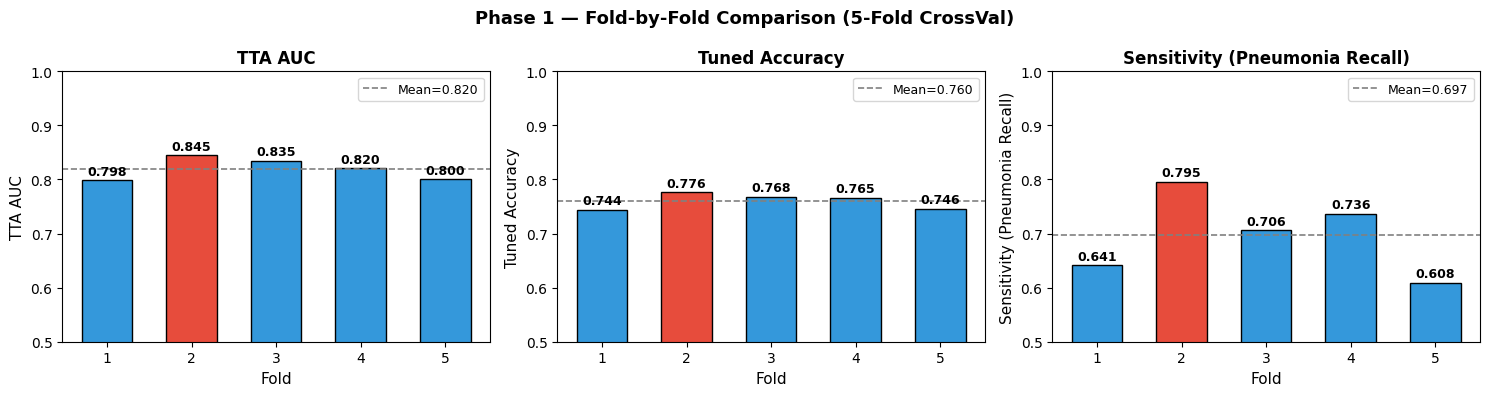

Red bar = best fold used for Phase 2 image encoder.


In [5]:
# --- CELL 3: Phase 1 Results Reference (Which fold is best?) ---
p1_csv = os.path.join(BASE_DIR, "outputs", "Phase_1.1v4_PA_crossval", "cv_results.csv")
p1_df  = pd.read_csv(p1_csv)

print("=== Phase 1 Fold-by-Fold Results ===")
print(p1_df[['fold','tta_auc','tuned_acc','tuned_f1','pn_recall','pn_spec','threshold']].to_string(index=False))

best_fold = int(p1_df.loc[p1_df['tta_auc'].idxmax(), 'fold'])
best_auc  = p1_df['tta_auc'].max()
print(f"\nBest fold : {best_fold}  (TTA AUC = {best_auc:.4f})")
print(f"Using checkpoint: best_model_fold{best_fold}.pth -> loaded as P1_CKPT")

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Phase 1 — Fold-by-Fold Comparison (5-Fold CrossVal)', fontsize=13, fontweight='bold')

colors = ['#e74c3c' if i+1 == best_fold else '#3498db' for i in range(5)]
for ax, col, ylabel in zip(axes,
                            ['tta_auc', 'tuned_acc', 'pn_recall'],
                            ['TTA AUC', 'Tuned Accuracy', 'Sensitivity (Pneumonia Recall)']):
    bars = ax.bar(p1_df['fold'].astype(str), p1_df[col], color=colors, edgecolor='black', width=0.6)
    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=12, fontweight='bold')
    ax.set_ylim(0.5, 1.0)
    ax.axhline(p1_df[col].mean(), color='gray', linestyle='--', lw=1.2, label=f'Mean={p1_df[col].mean():.3f}')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, p1_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'phase1_fold_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Red bar = best fold used for Phase 2 image encoder.")


In [6]:
# --- CELL 4: Read & Clean Radiology Reports (FINDINGS only, no IMPRESSION) ---
# WHY FINDINGS ONLY?
#  IMPRESSION contains the radiologist final label e.g. 'compatible with pneumonia'
#  which directly leaks the ground truth into the model input.
#  FINDINGS describes *what was observed* (opacity location/shape) so the model
#  must genuinely infer the diagnosis -- no cheating.

import re

# Patterns that directly reveal the label -- redact them
LEAKAGE_PATTERNS = [
    r'\bpneumonia\b', r'\bpneumonic\b',
    r'\bno[ -]acute[ -]\w+', r'\bno finding\w*',
    r'\bcompatible with\b', r'\bconsistent with\b',
    r'\bnormal study\b', r'\bno significant\b',
]
LEAKAGE_RE = re.compile('|'.join(LEAKAGE_PATTERNS), re.IGNORECASE)

def read_report(path):
    try:
        with open(path, encoding='utf-8', errors='ignore') as f:
            return f.read().strip()
    except Exception:
        return ''

def extract_findings_only(text):
    """Extract FINDINGS section only, stop before IMPRESSION."""
    m = re.search(
        r'FINDINGS[:\s]+(.*?)(?=IMPRESSION|CONCLUSION|\n\n|\Z)',
        text, re.DOTALL | re.IGNORECASE
    )
    if m:
        findings = m.group(1).strip()
    else:
        # Fallback: whole report minus IMPRESSION paragraph
        findings = re.sub(
            r'IMPRESSION[:\s]+.*?(\n\n|\Z)', '',
            text, flags=re.DOTALL | re.IGNORECASE
        ).strip()[:512]
    # Strip any residual label-leaking words
    findings = LEAKAGE_RE.sub('[REDACTED]', findings).strip()
    return findings if findings else text[:200]

df['report_text']  = df['report_path'].apply(read_report)
df['report_clean'] = df['report_text'].apply(extract_findings_only)

empty = (df['report_clean'].str.strip() == '').sum()
print(f'Empty after extraction : {empty}/{len(df)}')
print(f'Avg word count         : {df["report_clean"].str.split().str.len().mean():.1f}')
print('\nSample NORMAL (FINDINGS only, leakage removed):')
print(df[df['label']==0]['report_clean'].iloc[0][:400])
print('\nSample PNEUMONIA (FINDINGS only, leakage removed):')
print(df[df['label']==1]['report_clean'].iloc[0][:400])


Empty after extraction : 0/1989
Avg word count         : 43.3

Sample NORMAL (FINDINGS only, leakage removed):
The heart size is normal.  The hilar and mediastinal contours are
 unchanged.  Biapical scarring is persistent.  No focal consolidations
 concerning for [REDACTED] are identified.  There is no pleural effusion or
 pneumothorax.  The visualized osseous structures are unremarkable.

Sample PNEUMONIA (FINDINGS only, leakage removed):
There is dense retrocardiac opacity silhouetting the descending
 thoracic aorta and medial hemidiaphragm [REDACTED] a left lower lobe
 consolidation.  Elsewhere, the lungs are clear.  The cardiomediastinal
 silhouette is within normal limits.  Osseous and soft tissue structures are
 unremarkable.


In [7]:
# --- CELL 5: Train / Val / Test Split (70 / 15 / 15, stratified) ---
# First split off test (15%)
train_val_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df['label'], random_state=SEED
)
# Then split train vs val from the remaining 85%
val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)   # 0.15/0.85 ~ 0.176
train_df, val_df = train_test_split(
    train_val_df, test_size=val_frac, stratify=train_val_df['label'], random_state=SEED
)

for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n0 = (split['label'] == 0).sum()
    n1 = (split['label'] == 1).sum()
    print(f"{name:5s} : {len(split):5d}  (Normal={n0}, Pneumonia={n1})")


Train :  1391  (Normal=742, Pneumonia=649)
Val   :   299  (Normal=160, Pneumonia=139)
Test  :   299  (Normal=160, Pneumonia=139)


In [8]:
# --- CELL 6: Lung Bounding Box Lookup ---
bbox_df     = pd.read_csv(BBOX_CSV)
bbox_lookup = bbox_df.set_index('image_path').to_dict('index')
print(f"Bbox entries loaded: {len(bbox_lookup)}")


Bbox entries loaded: 354


In [9]:
# --- CELL 7: Multimodal Dataset Class ---
class MultimodalCXRDataset(Dataset):
    def __init__(self, df, bbox_lookup, tokenizer, img_transform, max_len=MAX_TEXT_LEN):
        self.df          = df.reset_index(drop=True)
        self.bbox_lookup = bbox_lookup
        self.tokenizer   = tokenizer
        self.transform   = img_transform
        self.max_len     = max_len
        self.clahe       = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # -- Image
        img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((224, 224), dtype=np.uint8)
        img = self.clahe.apply(img)
        bb  = self.bbox_lookup.get(row.image_path, None)
        if bb and bb.get('x_max', 0) > 0:
            img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
        img = Image.fromarray(img)
        img = self.transform(img)                        # (1, H, W)
        # -- Text
        enc = self.tokenizer(
            row.report_clean, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return (img,
                enc['input_ids'].squeeze(0),
                enc['attention_mask'].squeeze(0),
                int(row.label))

    def set_transform(self, t):
        self.transform = t

val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

print("Dataset class ready.")


Dataset class ready.


In [10]:
# --- CELL 8: Model Architecture ---

# ---- CBAM (same as Phase 1) ----
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels//reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels//reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return x * self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return x * self.sigmoid(self.conv(
            torch.cat([x.mean(dim=1,keepdim=True), x.max(dim=1,keepdim=True)[0]], dim=1)
        ))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention()
    def forward(self, x):
        return self.spatial_att(self.channel_att(x))


# ---- Image Encoder: Phase-1 weights (Fold 2, frozen) ----
class ImageEncoder(nn.Module):
    def __init__(self, ckpt_path):
        super().__init__()
        xrv_m         = xrv.models.DenseNet(weights='densenet121-res224-all')
        self.features = xrv_m.features
        self.cbam     = CBAM(1024, reduction=16)
        self.pool     = nn.AdaptiveAvgPool2d(1)
        # Load Phase-1 state dict
        sd     = torch.load(ckpt_path, map_location='cpu')
        enc_sd = {k: v for k, v in sd.items()
                  if k.startswith('features.') or k.startswith('cbam.')}
        miss, unexp = self.load_state_dict(enc_sd, strict=False)
        print(f"[ImageEncoder] loaded {len(enc_sd)} keys | "
              f"missing={len(miss)} | unexpected={len(unexp)}")
        for p in self.parameters():
            p.requires_grad = False   # frozen
    def forward(self, x):
        f = F.relu(self.features(x), inplace=True)
        f = self.cbam(f)
        return self.pool(f).flatten(1)     # (B, 1024)


# ---- Text Encoder: ClinicalBERT (frozen) ----
class TextEncoder(nn.Module):
    def __init__(self, model_name=CLINBERT_MODEL):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        for p in self.bert.parameters():
            p.requires_grad = False    # frozen
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]   # [CLS] -> (B, 768)


# ---- Fusion MLP (trainable) ----
class PneumoFusionNet(nn.Module):
    def __init__(self, img_dim=IMG_FEAT_DIM, txt_dim=TXT_FEAT_DIM, hidden=FUSION_HIDDEN):
        super().__init__()
        self.img_proj = nn.Linear(img_dim, hidden)
        self.txt_proj = nn.Linear(txt_dim, hidden)
        self.fusion   = nn.Sequential(
            nn.LayerNorm(hidden * 2),
            nn.Dropout(0.4),
            nn.Linear(hidden * 2, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )
    def forward(self, img_feat, txt_feat):
        i = F.relu(self.img_proj(img_feat))
        t = F.relu(self.txt_proj(txt_feat))
        return self.fusion(torch.cat([i, t], dim=1))

print("All model classes defined.")


All model classes defined.


In [11]:
# --- CELL 9: Instantiate Models, Tokenizer & DataLoaders ---
print("Loading ClinicalBERT tokenizer...")
tokenizer    = AutoTokenizer.from_pretrained(CLINBERT_MODEL)
text_encoder = TextEncoder(CLINBERT_MODEL).to(DEVICE)

print("Loading Phase-1 Image Encoder (Fold 2 checkpoint)...")
image_encoder = ImageEncoder(P1_CKPT).to(DEVICE)

fusion_model = PneumoFusionNet().to(DEVICE)

trainable = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
print(f"Fusion MLP trainable params: {trainable:,}")

# DataLoaders
train_ds = MultimodalCXRDataset(train_df, bbox_lookup, tokenizer, train_tfm)
val_ds   = MultimodalCXRDataset(val_df,   bbox_lookup, tokenizer, val_tfm)
test_ds  = MultimodalCXRDataset(test_df,  bbox_lookup, tokenizer, val_tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")


Loading ClinicalBERT tokenizer...
Loading Phase-1 Image Encoder (Fold 2 checkpoint)...
[ImageEncoder] loaded 728 keys | missing=0 | unexpected=0
Fusion MLP trainable params: 1,199,554
Train batches: 87 | Val: 19 | Test: 19


In [12]:
# --- CELL 10: Training Utilities ---
def run_epoch(fusion, img_enc, txt_enc, loader, optimizer, criterion, device, train=True):
    fusion.train(train); img_enc.eval(); txt_enc.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, input_ids, attn_masks, labels in loader:
            imgs, input_ids = imgs.to(device), input_ids.to(device)
            attn_masks, labels = attn_masks.to(device), labels.to(device)
            with torch.no_grad():
                img_feat = img_enc(imgs)
                txt_feat = txt_enc(input_ids, attn_masks)
            if train:
                optimizer.zero_grad()
            logits = fusion(img_feat, txt_feat)
            loss   = criterion(logits, labels)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(fusion.parameters(), 1.0)
                optimizer.step()
            probs = F.softmax(logits.detach(), dim=1)[:, 1].cpu().numpy()
            total_loss  += loss.item() * labels.size(0)
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().tolist())
    acc = accuracy_score(all_labels, [1 if p>=0.5 else 0 for p in all_probs])
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels))>1 else 0.5
    return total_loss/len(all_labels), acc, auc, all_probs, all_labels


def find_optimal_threshold(labels, probs):
    fpr, tpr, thresh = roc_curve(labels, probs)
    return float(thresh[np.argmax(tpr - fpr)])

print("Utilities defined.")


Utilities defined.


In [13]:
# --- CELL 11: Training Loop (Single Split) ---
# Class weights
n0 = (train_df['label'] == 0).sum()
n1 = (train_df['label'] == 1).sum()
weight    = torch.tensor([n1/(n0+n1), n0/(n0+n1)], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weight)

optimizer = torch.optim.AdamW(fusion_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_auc, best_state, patience_cnt = 0.0, None, 0
history = {'train_loss':[], 'val_loss':[], 'train_auc':[], 'val_auc':[]}

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc, tr_auc, _, _ = run_epoch(
        fusion_model, image_encoder, text_encoder,
        train_loader, optimizer, criterion, DEVICE, train=True)
    val_loss, val_acc, val_auc, _, _ = run_epoch(
        fusion_model, image_encoder, text_encoder,
        val_loader, optimizer, criterion, DEVICE, train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(val_auc)

    marker = ""
    if val_auc > best_auc:
        best_auc   = val_auc
        best_state = copy.deepcopy(fusion_model.state_dict())
        torch.save(best_state, os.path.join(SAVE_DIR, "best_fusion_model.pth"))
        patience_cnt = 0
        marker = " <-- best"
    else:
        patience_cnt += 1

    if epoch % 5 == 0 or marker:
        print(f"Ep {epoch:03d} | tr_loss={tr_loss:.4f} tr_auc={tr_auc:.4f} | "
              f"val_auc={val_auc:.4f} val_acc={val_acc:.3f}{marker}")

    if patience_cnt >= PATIENCE:
        print(f"Early stop at epoch {epoch}.")
        break

print(f"\nBest Val AUC: {best_auc:.4f}")


Ep 001 | tr_loss=0.5455 tr_auc=0.8011 | val_auc=0.8851 val_acc=0.816 <-- best
Ep 002 | tr_loss=0.4632 tr_auc=0.8637 | val_auc=0.8919 val_acc=0.829 <-- best
Ep 004 | tr_loss=0.4188 tr_auc=0.8928 | val_auc=0.8948 val_acc=0.809 <-- best
Ep 005 | tr_loss=0.3880 tr_auc=0.9079 | val_auc=0.9067 val_acc=0.849 <-- best
Ep 008 | tr_loss=0.3679 tr_auc=0.9174 | val_auc=0.9080 val_acc=0.856 <-- best
Ep 010 | tr_loss=0.3612 tr_auc=0.9216 | val_auc=0.9117 val_acc=0.843 <-- best
Ep 012 | tr_loss=0.3589 tr_auc=0.9242 | val_auc=0.9121 val_acc=0.846 <-- best
Ep 013 | tr_loss=0.3429 tr_auc=0.9292 | val_auc=0.9126 val_acc=0.846 <-- best
Ep 015 | tr_loss=0.3347 tr_auc=0.9324 | val_auc=0.9188 val_acc=0.856 <-- best
Ep 020 | tr_loss=0.2825 tr_auc=0.9521 | val_auc=0.9154 val_acc=0.860
Early stop at epoch 23.

Best Val AUC: 0.9188


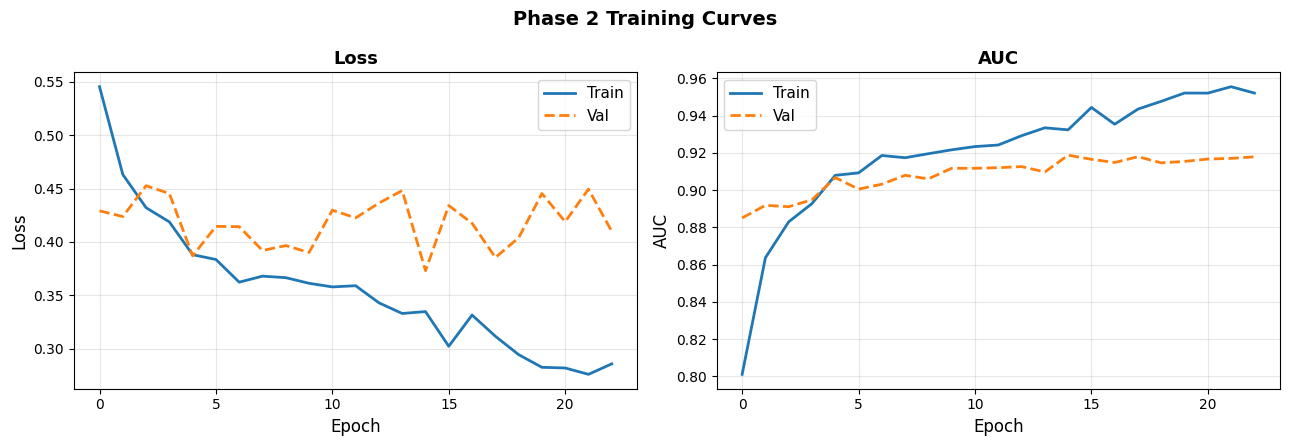

In [14]:
# --- CELL 12: Training Curves ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Phase 2 Training Curves', fontsize=14, fontweight='bold')

for ax, key, title in zip(axes,
                           [('train_loss','val_loss'), ('train_auc','val_auc')],
                           ['Loss', 'AUC']):
    k1, k2 = key
    ax.plot(history[k1], label='Train', lw=2)
    ax.plot(history[k2], label='Val',   lw=2, linestyle='--')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel(title,   fontsize=12)
    ax.set_title(title,    fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'phase2_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# --- CELL 13: Evaluate on Test Set ---
fusion_model.load_state_dict(best_state)
_, test_acc, test_auc, test_probs, test_labels = run_epoch(
    fusion_model, image_encoder, text_encoder,
    test_loader, None, criterion, DEVICE, train=False)

thresh      = find_optimal_threshold(test_labels, test_probs)
preds_tuned = [1 if p >= thresh   else 0 for p in test_probs]
preds_def   = [1 if p >= 0.5      else 0 for p in test_probs]

tuned_acc = accuracy_score(test_labels, preds_tuned)
tuned_f1  = f1_score(test_labels, preds_tuned)
cm_tuned  = confusion_matrix(test_labels, preds_tuned)
sens = cm_tuned[1,1] / (cm_tuned[1,0]+cm_tuned[1,1]) if (cm_tuned[1,0]+cm_tuned[1,1])>0 else 0
spec = cm_tuned[0,0] / (cm_tuned[0,0]+cm_tuned[0,1]) if (cm_tuned[0,0]+cm_tuned[0,1])>0 else 0

print(f"Test AUC         : {test_auc:.4f}")
print(f"Default Acc(0.5) : {test_acc:.4f}")
print(f"Tuned Acc        : {tuned_acc:.4f}  (threshold={thresh:.4f})")
print(f"Tuned F1         : {tuned_f1:.4f}")
print(f"Sensitivity      : {sens:.4f}")
print(f"Specificity      : {spec:.4f}")


Test AUC         : 0.9109
Default Acc(0.5) : 0.8395
Tuned Acc        : 0.8528  (threshold=0.5573)
Tuned F1         : 0.8358
Sensitivity      : 0.8058
Specificity      : 0.8938


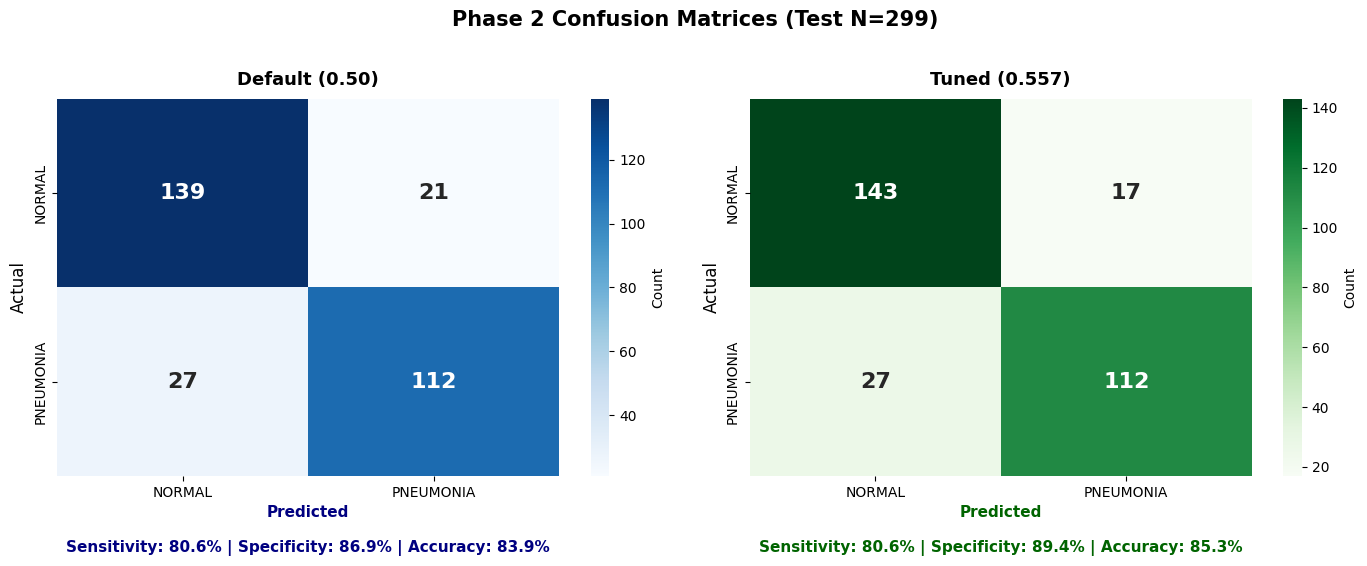

In [16]:
# --- CELL 14: Confusion Matrices (Default vs Tuned) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(f'Phase 2 Confusion Matrices (Test N={len(test_labels)})',
             fontsize=15, fontweight='bold', y=1.02)

for ax, preds, label, cmap, color in [
    (axes[0], preds_def,   f'Default (0.50)',     'Blues',  'navy'),
    (axes[1], preds_tuned, f'Tuned ({thresh:.3f})', 'Greens', 'darkgreen')
]:
    cm = confusion_matrix(test_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                cbar_kws={'label':'Count'}, annot_kws={'size':16,'weight':'bold'})
    s  = cm[1,1]/(cm[1,0]+cm[1,1]) if (cm[1,0]+cm[1,1])>0 else 0
    sp = cm[0,0]/(cm[0,0]+cm[0,1]) if (cm[0,0]+cm[0,1])>0 else 0
    ac = (cm[0,0]+cm[1,1])/cm.sum()
    ax.set_title(label, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Actual',    fontsize=12)
    ax.set_xlabel(
        f'Predicted\n\nSensitivity: {s:.1%} | Specificity: {sp:.1%} | Accuracy: {ac:.1%}',
        fontsize=11, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'phase2_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()


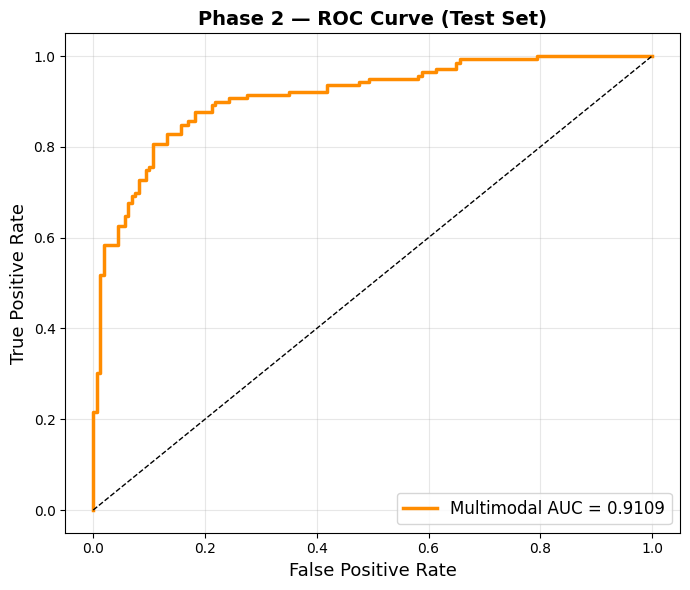

In [17]:
# --- CELL 15: ROC Curve ---
fpr, tpr, _ = roc_curve(test_labels, test_probs)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, lw=2.5, color='darkorange', label=f'Multimodal AUC = {test_auc:.4f}')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate',  fontsize=13)
ax.set_title('Phase 2 — ROC Curve (Test Set)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'phase2_roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()


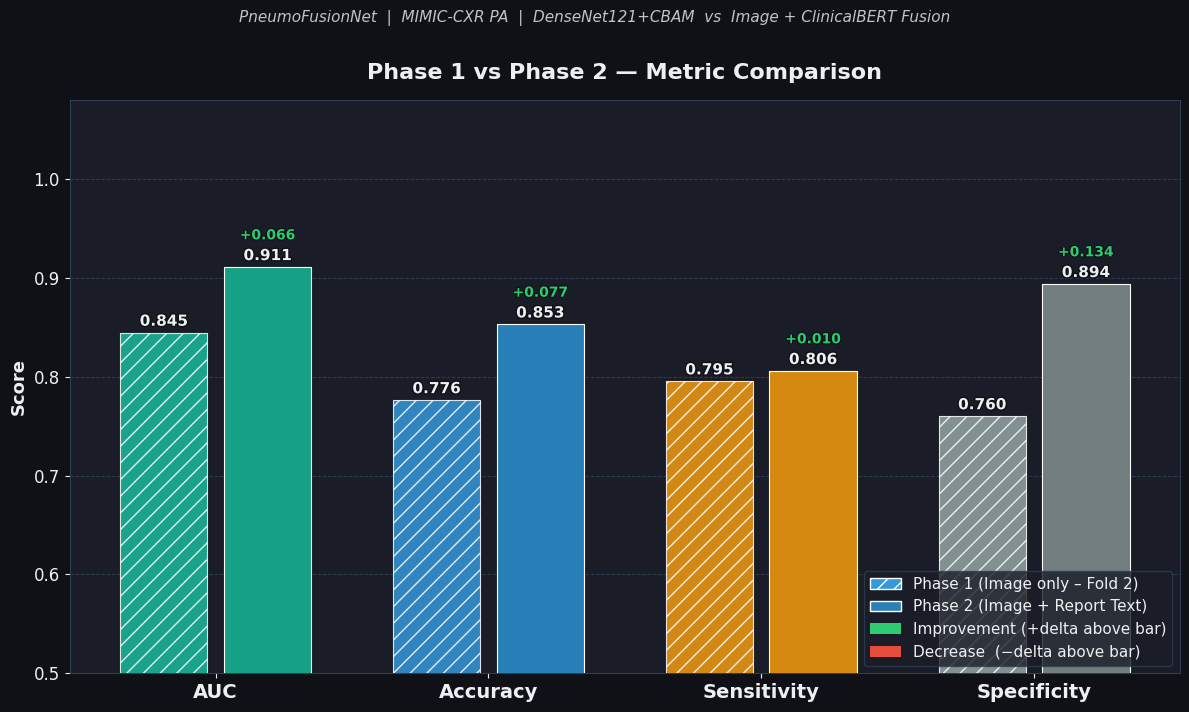


=== Phase 1 vs Phase 2 — Numeric Summary ===
Metric            Phase1   Phase2    Delta
-------------------------------------------
AUC               0.8445   0.9109 +0.0664
Accuracy          0.7763   0.8528 +0.0766
Sensitivity       0.7953   0.8058 +0.0104
Specificity       0.7600   0.8938 +0.1338


In [23]:
# --- CELL 16: Phase 1 vs Phase 2 — Comparison Chart ---
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

# ── Data ──────────────────────────────────────────────────────
p1_best = p1_df[p1_df['fold'] == best_fold].iloc[0]

metrics = ['AUC', 'Accuracy', 'Sensitivity', 'Specificity']
p1_vals = [float(p1_best['tta_auc']), float(p1_best['tuned_acc']),
           float(p1_best['pn_recall']), float(p1_best['pn_spec'])]
p2_vals = [float(test_auc), float(tuned_acc), float(sens), float(spec)]
deltas  = [p2 - p1 for p1, p2 in zip(p1_vals, p2_vals)]

# ── Style ──────────────────────────────────────────────────────
P1_COLORS = ['#1abc9c','#3498db','#f39c12','#95a5a6']
P2_COLORS = ['#16a085','#2980b9','#d68910','#717d7e']
BG_COLOR  = '#0f1117'
AX_COLOR  = '#1a1d27'
TEXT_CLR  = '#ecf0f1'
GRID_CLR  = '#2c3e50'

x, width, gap = np.arange(len(metrics)), 0.32, 0.06

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(AX_COLOR)
ax.spines[:].set_color(GRID_CLR)
ax.tick_params(colors=TEXT_CLR, labelsize=12)

# ── Bars ───────────────────────────────────────────────────────
bars1 = ax.bar(x - width/2 - gap/2, p1_vals, width,
               color=P1_COLORS, edgecolor='white', linewidth=0.8,
               alpha=0.85, hatch='//', zorder=3)
bars2 = ax.bar(x + width/2 + gap/2, p2_vals, width,
               color=P2_COLORS, edgecolor='white', linewidth=0.8,
               alpha=1.0, zorder=3)

# ── Value labels on Phase 1 bars ───────────────────────────────
for bar, val in zip(bars1, p1_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=TEXT_CLR,
            path_effects=[pe.withStroke(linewidth=2, foreground=BG_COLOR)])

# ── Value labels + delta on Phase 2 bars ───────────────────────
for bar, val, delta in zip(bars2, p2_vals, deltas):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=TEXT_CLR,
            path_effects=[pe.withStroke(linewidth=2, foreground=BG_COLOR)])
    sym = '+' if delta >= 0 else ''
    clr = '#2ecc71' if delta >= 0 else '#e74c3c'
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.025,
            f'{sym}{delta:.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=clr,
            path_effects=[pe.withStroke(linewidth=1.5, foreground=BG_COLOR)])

# ── Grid lines ─────────────────────────────────────────────────
for y_val in [0.6, 0.7, 0.8, 0.9, 1.0]:
    ax.axhline(y_val, color=GRID_CLR, linewidth=0.7, linestyle='--', zorder=1)

# ── Axis labels ────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=14, fontweight='bold', color=TEXT_CLR)
ax.set_ylim(0.50, 1.08)
ax.set_ylabel('Score', fontsize=13, color=TEXT_CLR, fontweight='bold')
ax.set_title('Phase 1 vs Phase 2 — Metric Comparison',
             fontsize=16, fontweight='bold', color=TEXT_CLR, pad=15)

# ── Legend ─────────────────────────────────────────────────────
p1_patch  = mpatches.Patch(facecolor='#3498db', hatch='//', edgecolor='white',
                            label='Phase 1 (Image only – Fold 2)')
p2_patch  = mpatches.Patch(facecolor='#2980b9', edgecolor='white',
                            label='Phase 2 (Image + Report Text)')
imp_patch = mpatches.Patch(facecolor='#2ecc71', label='Improvement (+delta above bar)')
dec_patch = mpatches.Patch(facecolor='#e74c3c', label='Decrease  (−delta above bar)')
ax.legend(handles=[p1_patch, p2_patch, imp_patch, dec_patch],
          fontsize=11, loc='lower right',
          facecolor=AX_COLOR, edgecolor=GRID_CLR, labelcolor=TEXT_CLR)

# ── Footer subtitle ────────────────────────────────────────────
fig.suptitle(
    'PneumoFusionNet  |  MIMIC-CXR PA  |  DenseNet121+CBAM  vs  Image + ClinicalBERT Fusion',
    fontsize=11, color='#bdc3c7', y=1.01, fontstyle='italic'
)

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'phase1_vs_phase2_comparison.png')
plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# ── Print table ────────────────────────────────────────────────
print('\n=== Phase 1 vs Phase 2 — Numeric Summary ===')
print(f'{"Metric":15s} {"Phase1":>8s} {"Phase2":>8s} {"Delta":>8s}')
print('-'*43)
for m, p1, p2, d in zip(metrics, p1_vals, p2_vals, deltas):
    print(f'{m:15s} {p1:>8.4f} {p2:>8.4f} {d:>+.4f}')


In [19]:
# --- CELL 17: Full Classification Report ---
print(f"Threshold: {thresh:.4f}")
print(classification_report(test_labels, preds_tuned, target_names=CLASSES))


Threshold: 0.5573
              precision    recall  f1-score   support

      NORMAL       0.84      0.89      0.87       160
   PNEUMONIA       0.87      0.81      0.84       139

    accuracy                           0.85       299
   macro avg       0.85      0.85      0.85       299
weighted avg       0.85      0.85      0.85       299



In [20]:
# --- CELL 18: Save Results ---
results = {
    'phase1_fold2_tta_auc':   float(p1_best['tta_auc']),
    'phase1_fold2_tuned_acc': float(p1_best['tuned_acc']),
    'phase2_test_auc':        float(test_auc),
    'phase2_tuned_acc':       float(tuned_acc),
    'phase2_tuned_f1':        float(tuned_f1),
    'phase2_sensitivity':     float(sens),
    'phase2_specificity':     float(spec),
    'threshold':              float(thresh),
    'test_n':                 len(test_labels),
}
with open(os.path.join(SAVE_DIR, 'phase2_results.json'), 'w') as f:
    json.dump(results, f, indent=2)
print("Results saved to:", os.path.join(SAVE_DIR, 'phase2_results.json'))
for k, v in results.items():
    print(f"  {k}: {v}")


Results saved to: c:\\2026\\PneumoFusionNet\\mimic\\1000_dataset\outputs\Phase_2_multimodal\phase2_results.json
  phase1_fold2_tta_auc: 0.8445029239766082
  phase1_fold2_tuned_acc: 0.7762803234501348
  phase2_test_auc: 0.9108812949640287
  phase2_tuned_acc: 0.8528428093645485
  phase2_tuned_f1: 0.835820895522388
  phase2_sensitivity: 0.8057553956834532
  phase2_specificity: 0.89375
  threshold: 0.5573075413703918
  test_n: 299
